In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Refinement
Fonction qui va permettre de refine le topolical graphe initial, avec marge d'erreur de 2px

In [12]:
from skimage import io
from meta import ROOT_DIR
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from bez.topo_graph import visualize_subgraph, extract_topology_from_skeleton, extract_simple_topology_from_skeleton, image_to_skeleton
from bez.graph_to_bezier import bezier_from_graph, visualize_bezier_fits
from bez.refinement import  refine
from bez.hypergraph import HyperGraph
from bez.global_optim import optimisation, show_SVG

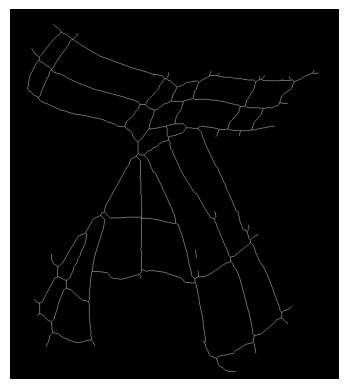

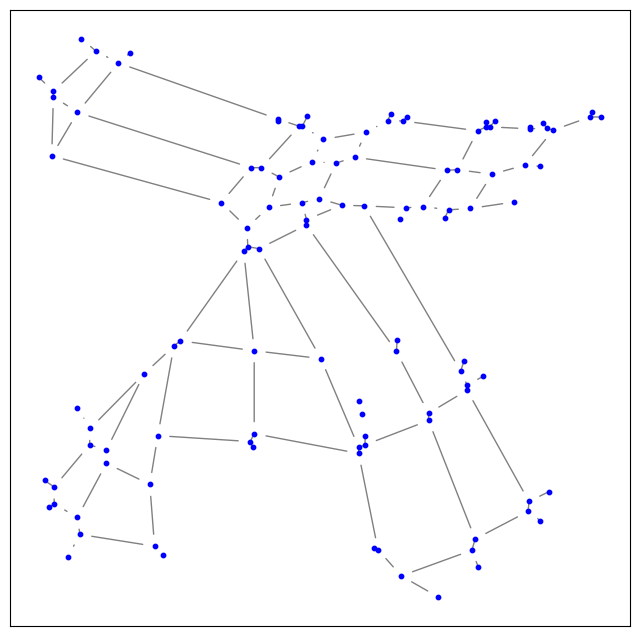

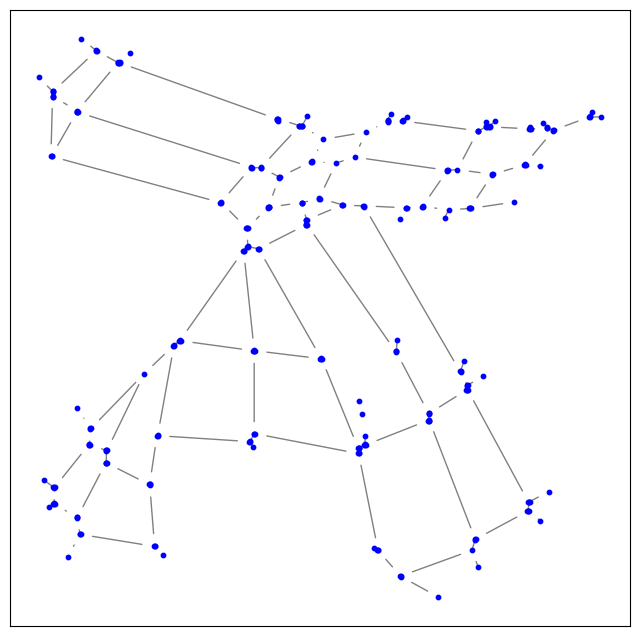

In [13]:
# Skeleton extraction
img = io.imread(ROOT_DIR /"data/original_paper/figure_1/input.png") # [165:190, 220:270, :]

skeletone, thikness = image_to_skeleton(img)
plt.imshow(skeletone, cmap="gray")
plt.axis("off")
plt.show()

topo_graph = extract_simple_topology_from_skeleton(skeletone)
visualize_subgraph(topo_graph, full_graph=True)

topo_graph_ = extract_topology_from_skeleton(skeletone)
visualize_subgraph(topo_graph_, full_graph=True)

# bezier_curves = bezier_from_graph(topo_graph)
# visualize_bezier_fits(img, bezier_curves)

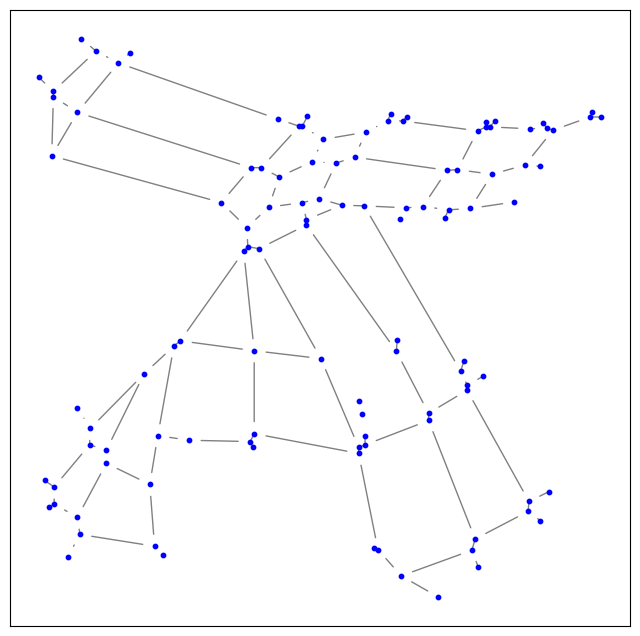

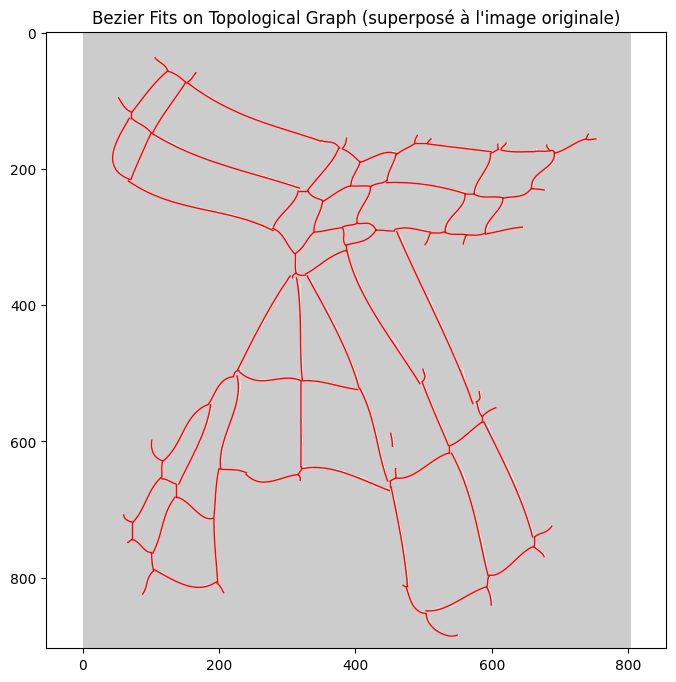

In [14]:
topo_graph = refine(topo_graph)
# visualize_subgraph(topo_graph, full_graph=True)
visualize_subgraph(topo_graph, full_graph=True)

new_bezier_curves = bezier_from_graph(topo_graph)
# visualize_bezier_fits(skeletone, bezier_curves)
visualize_bezier_fits(skeletone, new_bezier_curves)


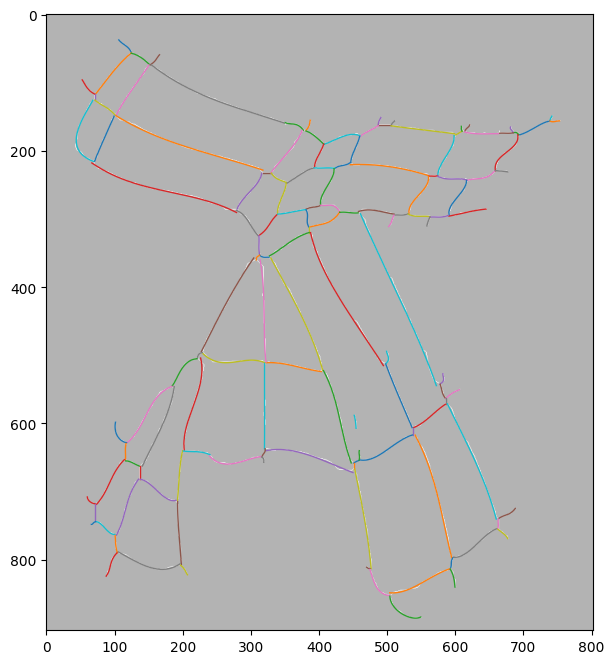

In [15]:
hyper = HyperGraph(topo_graph)
show_SVG(hyper, skeletone)

# param
lam = 0.8
temp = 1
mu = 0.3
t_decrease = 0.999 ** (1/len(topo_graph.nodes))
t_min = 0.05

In [16]:
error = optimisation(hyper, lam, mu, temp, t_decrease, t_min)


  0%|          | 356/500000 [00:00<02:34, 3224.07it/s]

0.9999910670012068


  2%|▏         | 10449/500000 [00:03<02:12, 3692.22it/s]

0.9145352008665913


  4%|▍         | 20330/500000 [00:06<02:48, 2842.85it/s]

...

 64%|██████▍   | 320386/500000 [01:46<00:57, 3111.88it/s]

0.05735006427235776


 66%|██████▌   | 330585/500000 [01:50<00:52, 3256.21it/s]

0.05244912107696801


 67%|██████▋   | 335354/500000 [01:51<00:54, 3002.09it/s]


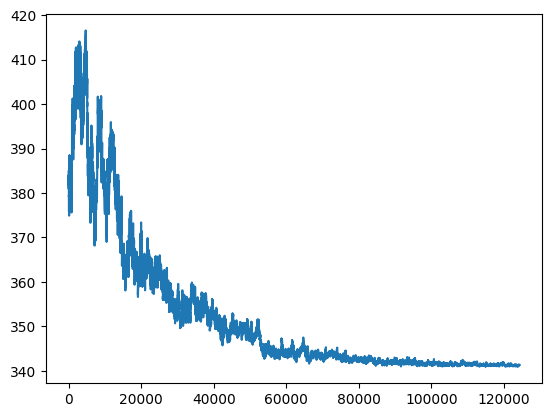

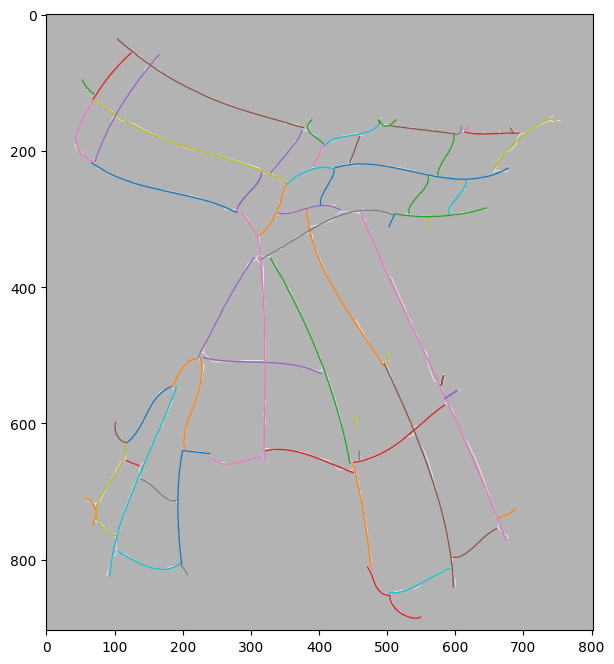

In [17]:
plt.plot(range(len(error)), error)
show_SVG(hyper, skeletone)